# Macaulay DCF Equity Duration (EURO500)

Dieses Notebook berechnet die Macaulay DCF Equity Duration nach deiner Definition mit:
- Horizont: `T = 3`
- Diskontsatz: `r = 8%`
- Terminal-Wachstum: `g = 2%`

Cashflows werden als `C_{i,s} = EPS_{i,s}` interpretiert.


## Definition: EQ Duration (Macaulay DCF) im Notebook

Dieses Notebook berechnet pro Firma $i$ und As-of-Datum die **Macaulay DCF Equity Duration** mit:

- Forecast-Horizont: $T = 3$
- Diskontsatz: $r = 0.08$
- Terminal-Wachstum: $g = 0.02$
- Cashflows: $C_{i,1}, C_{i,2}, C_{i,3}$ aus den Spalten `EPS_FY1..EPS_FY3` (Fallback-Logik im Code erlaubt alternativ `NPS_FY1..NPS_FY3` bzw. `FY1..FY3`).

### 1) Barwerte

$$
PV_i^F = \sum_{s=1}^{3} \frac{C_{i,s}}{(1+r)^s}
$$

$$
TV_i = \frac{C_{i,3}(1+g)}{r-g}, \qquad PV_i^{TV} = \frac{TV_i}{(1+r)^3}
$$

$$
P_i^{DCF} = PV_i^F + PV_i^{TV}
$$

### 2) Macaulay Duration

$$
D_i = \frac{1}{P_i^{DCF}}\left[ \sum_{s=1}^{3} s\cdot\frac{C_{i,s}}{(1+r)^s} + \left(3 + \frac{1+r}{r-g}\right)\cdot\frac{TV_i}{(1+r)^3} \right]
$$

Im Code entspricht das:

- `PV_F`, `TV`, `PV_TV`, `P_DCF`
- `Duration_num` = Zähler der Formel
- `Duration_DCF_Macaulay` = `Duration_num / P_DCF`

### 3) Gültigkeitsregel (`status`)

- `status = 'ok'`, falls `P_DCF > 0` und nicht fehlend.
- sonst `status = 'invalid_P_DCF_nonpositive_or_missing'` und `Duration_DCF_Macaulay = NaN`.

### 4) Gespeicherter Output

Ergebnisdatei: `Project_Data/intermediate/EQDuration_Macaulay.parquet`
mit der zentralen Zielgröße `Duration_DCF_Macaulay`.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

BASE_DIR = Path('/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data')
DATA_DIR = BASE_DIR / 'intermediate'

R = 0.08
G = 0.02
T = 3

if R <= G:
    raise ValueError(f'Need r > g. Got r={R}, g={G}')

print('Data dir:', DATA_DIR)
print('Parameters:', {'T': T, 'r': R, 'g': G})


Data dir: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate
Parameters: {'T': 3, 'r': 0.08, 'g': 0.02}


In [2]:
# 1) Tabelle laden: primär EURO500_NPS, sonst Fallback
candidate_files = [
    'euro500_x_EPS.parquet',
]

selected_path = None
for name in candidate_files:
    p = DATA_DIR / name
    if p.exists():
        selected_path = p
        break

if selected_path is None:
    raise FileNotFoundError('Keine passende Input-Tabelle gefunden (EURO500_NPS/EURO500_EPS/cfps_forecasts).')

df = pd.read_parquet(selected_path).copy()
print('Loaded:', selected_path)
print('Shape:', df.shape)
print('Columns (first 30):', list(df.columns)[:30])


Loaded: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500_x_EPS.parquet
Shape: (54000, 29)
Columns (first 30): ['date', 'formation_date', 'effective_date', 'quarter', 'RIC', 'name', 'hq_country', 'hq_code', 'trbc_sector_code', 'trbc_sector', 'mcap_eur', 'RIC_snapshot', 'RIC_current', 'ISIN', 'SEDOL', 'FreeFloat', 'FreeFloatPct', 'Volume', 'PriceClose', 'InstrumentType', 'firm_id', 'rank_mcap', 'asof_date', 'pull_ric', 'EPS_FY1', 'EPS_FY2', 'EPS_FY3', 'EPS_FY4', 'EPS_FY5']


In [3]:
# 2) Cashflow-Spalten robust erkennen
cashflow_sets = [
    ('NPS_FY1', 'NPS_FY2', 'NPS_FY3'),
    ('EPS_FY1', 'EPS_FY2', 'EPS_FY3'),
    ('FY1', 'FY2', 'FY3'),
]

chosen = None
for c1, c2, c3 in cashflow_sets:
    if all(c in df.columns for c in (c1, c2, c3)):
        chosen = (c1, c2, c3)
        break

if chosen is None:
    raise KeyError('Keine passenden 3Y-Cashflow-Spalten gefunden. Erwartet z.B. EPS_FY1..EPS_FY3 oder NPS_FY1..NPS_FY3.')

c1_col, c2_col, c3_col = chosen
print('Using cashflow columns:', chosen)

id_candidates = ['RIC', 'firm_id', 'name', 'date', 'asof_date', 'quarter', 'year']
id_cols = [c for c in id_candidates if c in df.columns]
print('ID columns used:', id_cols)


Using cashflow columns: ('EPS_FY1', 'EPS_FY2', 'EPS_FY3')
ID columns used: ['RIC', 'firm_id', 'name', 'date', 'asof_date', 'quarter']


In [4]:
# 3) Macaulay DCF Equity Duration berechnen
work = df.copy()
for c in [c1_col, c2_col, c3_col]:
    work[c] = pd.to_numeric(work[c], errors='coerce').astype('float64')

C1 = work[c1_col]
C2 = work[c2_col]
C3 = work[c3_col]

disc1 = (1 + R) ** 1
disc2 = (1 + R) ** 2
disc3 = (1 + R) ** 3

work['PV_F'] = C1 / disc1 + C2 / disc2 + C3 / disc3
work['TV'] = C3 * (1 + G) / (R - G)
work['PV_TV'] = work['TV'] / disc3
work['P_DCF'] = work['PV_F'] + work['PV_TV']

dur_forecast_num = 1 * (C1 / disc1) + 2 * (C2 / disc2) + 3 * (C3 / disc3)
dur_tv_num = (T + (1 + R) / (R - G)) * work['PV_TV']
work['Duration_num'] = dur_forecast_num + dur_tv_num

valid = work['P_DCF'].notna() & (work['P_DCF'] > 0)
work['Duration_DCF_Macaulay'] = np.nan
work.loc[valid, 'Duration_DCF_Macaulay'] = (
    work.loc[valid, 'Duration_num'] / work.loc[valid, 'P_DCF']
)
work['status'] = np.where(valid, 'ok', 'invalid_P_DCF_nonpositive_or_missing')

res_cols = id_cols + [
    c1_col, c2_col, c3_col,
    'PV_F', 'TV', 'PV_TV', 'P_DCF',
    'Duration_num', 'Duration_DCF_Macaulay', 'status'
]
result = work[res_cols].copy()

print(result['status'].value_counts(dropna=False))
print('Valid share:', float((result['status'] == 'ok').mean()))
result.head(10)


status
ok                                      44459
invalid_P_DCF_nonpositive_or_missing     9541
Name: count, dtype: int64
Valid share: 0.8233148148148148


,RIC,firm_id,name,date,asof_date,quarter,EPS_FY1,EPS_FY2,EPS_FY3,PV_F,TV,PV_TV,P_DCF,Duration_num,Duration_DCF_Macaulay,status
0,FTE.PA,FIRM0001344,Orange SA,1998-12-31,1998-12-31,1999Q1,1.82531,2.05258,2.32465,5.295240,39.51905,31.371496,36.666737,669.547178,18.260343,ok
1,OLIV.MI,FIRM0001885,Telecom Italia SpA,1998-12-31,1998-12-31,1999Q1,-0.02329,0.01357,0.03909,0.021100,0.66453,0.527525,0.548626,11.172828,20.365127,ok
2,NOKIA.HE,FIRM0000965,Nokia Oyj,1998-12-31,1998-12-31,1999Q1,0.32845,0.38263,0.44510,0.985499,7.56670,6.006690,6.992189,128.160710,18.329125,ok
3,ENI.MI,FIRM0001944,Eni SpA,1998-12-31,1998-12-31,1999Q1,0.62751,0.66909,0.75986,1.757866,12.91762,10.254423,12.012289,218.880793,18.221406,ok
4,DCXGn.DE,FIRM0000456,Mercedes-Benz Group AG,1998-12-31,1998-12-31,1999Q1,4.93516,6.28406,6.89331,15.429293,117.18627,93.026239,108.455532,1985.312151,18.305310,ok
5,OREP.PA,FIRM0001301,L'Oreal SA,1998-12-31,1998-12-31,1999Q1,1.05780,1.18829,1.36275,3.080006,23.16675,18.390513,21.470520,392.463138,18.279164,ok
6,TEF.MC,FIRM0000947,Telefonica SA,1998-12-31,1998-12-31,1999Q1,0.29697,0.34545,0.40760,0.894706,6.92920,5.500622,6.395328,117.351075,18.349500,ok
7,TYC.N,FIRM0000167,Johnson Controls International PLC,1998-12-31,1998-12-31,1999Q1,5.81437,7.28796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,invalid_P_DCF_nonpositive_or_missing
8,EAUG.PA,FIRM0001332,Vivendi SE,1998-12-31,1998-12-31,1999Q1,2.02372,2.52568,2.88242,6.327336,49.00114,38.898685,45.226021,829.941396,18.350971,ok
9,MDT.N,FIRM0001853,Medtronic PLC,1998-12-31,1998-12-31,1999Q1,0.76278,0.92591,1.07500,2.353466,18.27500,14.507284,16.860750,309.506992,18.356656,ok


In [5]:
# 4) Plausibilitätscheck (nur gültige Zeilen)
ok = result[result['status'] == 'ok'].copy()
if len(ok) == 0:
    print('No valid rows found.')
else:
    print(ok['Duration_DCF_Macaulay'].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))
    if 'year' in ok.columns:
        print('Rows per year (head):')
        print(ok.groupby('year').size().head(10))


count    44459.000000
mean        18.436986
std          3.836037
min       -115.279700
1%          17.315099
5%          17.884960
50%         18.242354
95%         19.078917
99%         21.446348
max        496.877813
Name: Duration_DCF_Macaulay, dtype: float64


In [6]:
# 5) Speichern
out_path = DATA_DIR / 'EQDuration_Macaulay.parquet'
result.to_parquet(out_path, index=False)
print('Saved:', out_path)


Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/EQDuration_Macaulay.parquet


## 6) Analyse: Datenqualität und Verteilung

Diese Sektion prüft, wie belastbar das Duration-Maß ist (Validität, Ausreißer, Verteilung).


,metric,value
0,rows_total,54000.000000
1,rows_ok,44459.000000
2,rows_invalid,9541.000000
3,ok_share,0.823315
4,share_missing_any_CF,0.166889
5,share_nonpositive_P_DCF,0.009796


Duration describe (ok only):


count    44459.000000
mean        18.436986
std          3.836037
min       -115.279700
1%          17.315099
5%          17.884960
25%         18.132074
50%         18.242354
75%         18.411236
95%         19.078917
99%         21.446348
max        496.877813
Name: Duration_DCF_Macaulay, dtype: float64

Winsorized 1%-99% describe (ok only):


count    44459.000000
mean        18.344995
std          0.513530
min         17.315099
1%          17.315315
5%          17.884960
25%         18.132074
50%         18.242354
75%         18.411236
95%         19.078917
99%         21.445794
max         21.446348
Name: Duration_DCF_Macaulay, dtype: float64

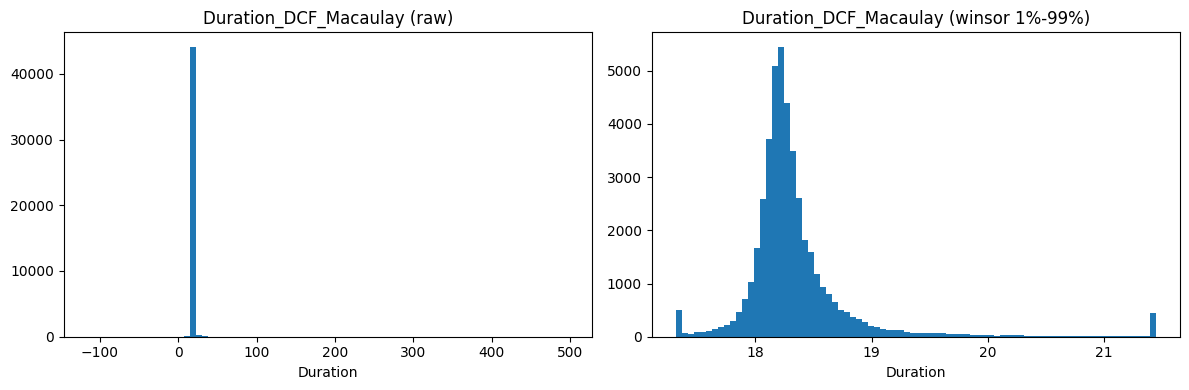

In [7]:
import matplotlib.pyplot as plt

ana = result.copy()
ana['is_ok'] = ana['status'].eq('ok')

n_total = len(ana)
n_ok = int(ana['is_ok'].sum())
n_bad = n_total - n_ok

cf_missing = ana[[c1_col, c2_col, c3_col]].isna().any(axis=1)
pdcf_nonpos = ana['P_DCF'].notna() & (ana['P_DCF'] <= 0)

quality = pd.DataFrame({
    'metric': [
        'rows_total',
        'rows_ok',
        'rows_invalid',
        'ok_share',
        'share_missing_any_CF',
        'share_nonpositive_P_DCF'
    ],
    'value': [
        n_total,
        n_ok,
        n_bad,
        n_ok / n_total if n_total else np.nan,
        float(cf_missing.mean()),
        float(pdcf_nonpos.mean())
    ]
})
display(quality)

d_ok = ana.loc[ana['is_ok'], 'Duration_DCF_Macaulay'].dropna()
print('Duration describe (ok only):')
display(d_ok.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

d_w = d_ok.clip(lower=d_ok.quantile(0.01), upper=d_ok.quantile(0.99))
print('Winsorized 1%-99% describe (ok only):')
display(d_w.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(d_ok, bins=80)
ax[0].set_title('Duration_DCF_Macaulay (raw)')
ax[0].set_xlabel('Duration')

ax[1].hist(d_w, bins=80)
ax[1].set_title('Duration_DCF_Macaulay (winsor 1%-99%)')
ax[1].set_xlabel('Duration')
plt.tight_layout()
plt.show()


## 7) Analyse: Zeit- und Sektorstabilität


,year,n,p10,median,p90,mean
0,1998,275,18.090221,18.320663,18.771768,18.425416
1,1999,1182,18.095598,18.325551,18.792323,18.467037
2,2000,1306,18.047410,18.337500,18.856261,18.486910
3,2001,1359,18.029883,18.323424,18.842357,18.686611
4,2002,1345,18.044514,18.336909,18.915559,18.585154
5,2003,1367,18.035195,18.300611,19.003821,18.549235
6,2004,1407,18.008954,18.269762,18.757152,18.472010
7,2005,1407,18.000114,18.238902,18.566465,18.298589
8,2006,1493,18.017772,18.252477,18.647740,18.323427
9,2007,1610,18.009131,18.259653,18.554256,18.278661


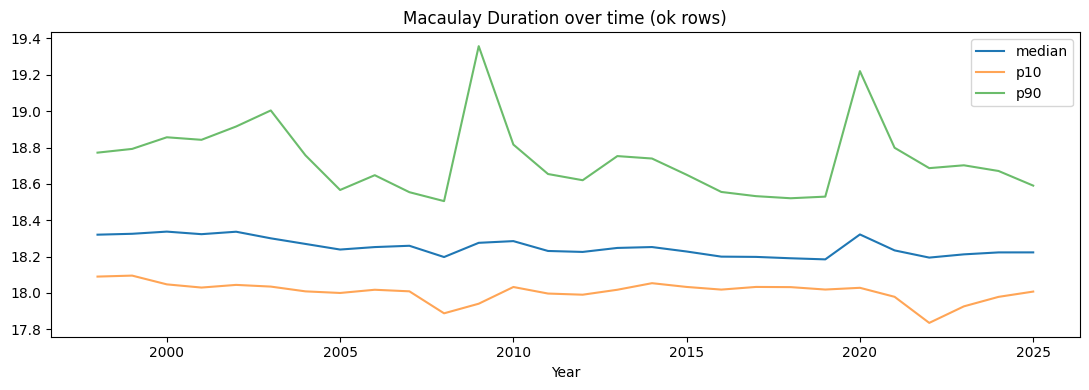

,n,median,mean
trbc_sector,,,
Technology,6431,18.288313,18.675538
Healthcare,3928,18.276625,18.552055
Consumer Cyclicals,7891,18.275155,18.434657
Industrials,9997,18.258339,18.488216
Basic Materials,5071,18.237494,18.370367
Consumer Non-Cyclicals,3824,18.211109,18.262533
Energy,2355,18.196975,18.397945
"Institutions, Associations & Organizations",16,18.163492,18.166746
Utilities,2610,18.120449,18.173295


In [8]:
ana = result.copy()
if 'asof_date' in ana.columns:
    ana['year'] = pd.to_datetime(ana['asof_date']).dt.year
elif 'date' in ana.columns:
    ana['year'] = pd.to_datetime(ana['date']).dt.year
else:
    ana['year'] = np.nan

ok = ana[ana['status'].eq('ok')].copy()

year_stats = ok.groupby('year')['Duration_DCF_Macaulay'].agg(
    n='count', p10=lambda x: x.quantile(0.10), median='median', p90=lambda x: x.quantile(0.90), mean='mean'
).reset_index()
display(year_stats.head(20))

fig, ax = plt.subplots(1, 1, figsize=(11, 4))
ax.plot(year_stats['year'], year_stats['median'], label='median')
ax.plot(year_stats['year'], year_stats['p10'], label='p10', alpha=0.7)
ax.plot(year_stats['year'], year_stats['p90'], label='p90', alpha=0.7)
ax.set_title('Macaulay Duration over time (ok rows)')
ax.set_xlabel('Year')
ax.legend()
plt.tight_layout()
plt.show()

# Sector merge (if sector exists in source table)
sec_path = DATA_DIR / 'euro500_x_EPS.parquet'
if sec_path.exists() and all(c in ok.columns for c in ['RIC', 'quarter', 'asof_date']):
    sec = pd.read_parquet(sec_path)[['RIC', 'quarter', 'asof_date', 'trbc_sector']].copy()
    sec['asof_date'] = pd.to_datetime(sec['asof_date'])
    ok['asof_date'] = pd.to_datetime(ok['asof_date'])
    ok_sec = ok.merge(sec.drop_duplicates(['RIC', 'quarter', 'asof_date']), on=['RIC', 'quarter', 'asof_date'], how='left')
    sec_stats = ok_sec.groupby('trbc_sector')['Duration_DCF_Macaulay'].agg(n='count', median='median', mean='mean').sort_values('median', ascending=False)
    display(sec_stats.head(15))
else:
    print('Sector stability skipped: required columns or file missing.')


## 9) Analyse: Einfacher Zins-Shock-Test (Long HighD - Short LowD)

Idee: Pro Quartal Duration-Quintile bilden und tägliches Portfolio-Return-Minus (`Q5 - Q1`) auf `dy` (2Y OIS-Änderung) regressieren.
Erwartung bei restriktiven Schocks: negativer Koeffizient.


In [10]:
rets_path = DATA_DIR / 'daily_returns_euro500_in_index.parquet'
ois_path = DATA_DIR / 'rates_2yOIS_daily.parquet'

if not (rets_path.exists() and ois_path.exists()):
    print('Missing required files for shock test.')
else:
    dur_q = result[result['status'].eq('ok')][['RIC', 'quarter', 'Duration_DCF_Macaulay']].copy()
    dur_q = dur_q.dropna().drop_duplicates(['RIC', 'quarter'])

    # quintiles within quarter
    dur_q['q'] = dur_q.groupby('quarter')['Duration_DCF_Macaulay'].transform(
        lambda s: pd.qcut(s.rank(method='first'), 5, labels=[1,2,3,4,5])
    )

    rets = pd.read_parquet(rets_path)[['date', 'quarter', 'RIC', 'ret']].copy()
    rets['date'] = pd.to_datetime(rets['date'])
    rets['ret'] = pd.to_numeric(rets['ret'], errors='coerce')

    px = rets.merge(dur_q[['RIC', 'quarter', 'q']], on=['RIC', 'quarter'], how='inner')
    px = px.dropna(subset=['ret', 'q'])

    q_daily = px.groupby(['date', 'q'])['ret'].mean().reset_index()
    q_wide = q_daily.pivot(index='date', columns='q', values='ret')
    q_wide['LS_5m1'] = q_wide[5] - q_wide[1]

    ois = pd.read_parquet(ois_path).copy()
    ois['date'] = pd.to_datetime(ois['date'])
    ois['dy'] = pd.to_numeric(ois['dy'], errors='coerce')

    reg = q_wide[['LS_5m1']].merge(ois[['date', 'dy']].set_index('date'), left_index=True, right_index=True, how='inner').dropna()

    # OLS via numpy: LS = a + b*dy
    y = reg['LS_5m1'].to_numpy()
    x = reg['dy'].to_numpy()
    X = np.column_stack([np.ones(len(x)), x])
    beta = np.linalg.lstsq(X, y, rcond=None)[0]

    yhat = X @ beta
    resid = y - yhat
    n = len(y)
    k = X.shape[1]
    s2 = (resid @ resid) / max(n - k, 1)
    vcov = s2 * np.linalg.inv(X.T @ X)
    se = np.sqrt(np.diag(vcov))
    tvals = beta / se

    out = pd.DataFrame({
        'coef': beta,
        'std_err': se,
        't_value': tvals
    }, index=['const', 'dy'])

    print('Regression: LS_5m1 ~ const + dy')
    print('n_obs:', n)
    display(out)

    print('Average LS_5m1 daily return:', reg['LS_5m1'].mean())


Regression: LS_5m1 ~ const + dy
n_obs: 4243


/var/folders/r2/vtz74sz14fx185wt9m3c781w0000gn/T/ipykernel_37177/885919197.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  q_daily = px.groupby(['date', 'q'])['ret'].mean().reset_index()


,coef,std_err,t_value
const,0.000116,0.000093,1.244475
dy,0.018833,0.002638,7.140106


Average LS_5m1 daily return: 0.00011966468270628788
